# Regularized Regression — Notebook 03 · Elastic Net and the Grouping Effect

**Regularized Regression — From Likelihood to Lasso**

Covers **Task 4**: build a correlated group, show that the three estimators handle it in three distinguishable ways, then *measure* selection stability with a bootstrap instead of asserting it.

---

### How to run this

Put `uber_surge_mumbai.csv` (and, for notebook 02, `new_city_features.csv` and
`new_city_truth.csv`) in a `data/` folder beside this notebook, or upload them to your
Colab session. If the files are missing, the next cell regenerates them from the same
seed, so nothing here breaks either way.

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=110)
pd.set_option('display.width', 120, 'display.max_columns', 30)

# --- a consistent look for every figure in this course -----------------------
plt.rcParams.update({
    'figure.figsize': (9, 4.6), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': .28, 'grid.linewidth': .7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cbc3', 'axes.labelcolor': '#4c514f',
    'axes.titlesize': 12, 'axes.titleweight': '600', 'axes.labelsize': 10,
    'xtick.color': '#767d7a', 'ytick.color': '#767d7a',
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.frameon': False, 'legend.fontsize': 9,
    'font.size': 10, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
C = {'ols': '#767d7a', 'ridge': '#2b5fa8', 'lasso': '#b4700c',
     'enet': '#5b4bb5', 'accent': '#1f6f5c', 'rose': '#b03a52'}

# Look in the usual places: beside the notebook, in ./data, or one level up
# (which is where the repo keeps them if you opened this from notebooks/).
SEARCH = ['data', '.', '../data', '..', '../../data']

def load(name):
    """Load a course CSV, regenerating it from the seed if it cannot be found."""
    for d in SEARCH:
        path = os.path.join(d, name)
        if os.path.exists(path):
            return pd.read_csv(path)
    for cand in ('scripts/make_data.py', 'make_data.py', '../scripts/make_data.py'):
        if os.path.exists(cand):
            subprocess.run([sys.executable, cand], check=True)
            return load(name)
    raise FileNotFoundError(
        f"{name} not found. Download it from the course site's Data page and put it "
        f"in a data/ folder beside this notebook.")

df = load('uber_surge_mumbai.csv')
print(f'{len(df)} trips, {df.shape[1]} columns')
df.head(3)

200 trips, 19 columns


,trip_id,zone,hour,is_peak,is_weekend,is_rain,is_event_nearby,is_airport_pickup,traffic_speed_kmph,drivers_available_500m,open_requests_500m,historical_demand,distance_km,time_min,base_fare_inr,surge_additive_inr,final_fare_inr,demand_supply_ratio,is_bad_weather
0,1,Powai,2,0,1,0,0,0,43.4,31,13,14.0,18.21,33.6,325.7,27.8,353.5,0.419,0
1,2,Lower Parel,18,1,0,1,1,0,22.8,6,46,46.2,15.06,42.7,306.1,150.0,456.1,7.667,1
2,3,Andheri East,15,0,0,0,1,0,47.3,17,25,26.4,3.24,7.8,94.5,65.7,160.2,1.471,0


In [2]:
# ---------------------------------------------------------------------------
# Conventions used throughout this course. Read these once; they save hours.
#
#   Objective (identical to sklearn's ElasticNet, including the 1/2n):
#       (1/2n)||y - Xw||^2  +  alpha*rho*||w||_1  +  (alpha*(1-rho)/2)*||w||^2
#
#   So the Ridge CLOSED FORM needs  n*alpha  where sklearn's Ridge takes alpha:
#       w = (X^T X + n*alpha*I)^-1 X^T y
#
#   Standardize on the TRAINING rows only, then apply that scaler to the test
#   rows. Split by time, never shuffled: trips 1-150 train, 151-200 test.
# ---------------------------------------------------------------------------
BASE8 = ['is_peak', 'is_rain', 'traffic_speed_kmph', 'drivers_available_500m',
         'is_event_nearby', 'is_airport_pickup', 'is_weekend', 'open_requests_500m']
SHORT = {'is_peak': 'is_peak', 'is_rain': 'is_rain',
         'traffic_speed_kmph': 'traffic_speed', 'drivers_available_500m': 'drivers_avail',
         'is_event_nearby': 'is_event', 'is_airport_pickup': 'is_airport',
         'is_weekend': 'is_weekend', 'open_requests_500m': 'open_requests',
         'is_bad_weather': 'is_bad_weather'}
N_TRAIN, SIGMA, TAU = 150, 10.0, 1.0

def split(frame, features):
    X = frame[features].to_numpy(float)
    y = frame['surge_additive_inr'].to_numpy(float)
    return X[:N_TRAIN], X[N_TRAIN:], y[:N_TRAIN], y[N_TRAIN:]

def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(0), Xtr.std(0)
    sd = np.where(sd == 0, 1e-8, sd)
    return (Xtr - mu) / sd, (Xte - mu) / sd, mu, sd

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def r2(y, yhat):
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))

print('conventions loaded')

conventions loaded


In [3]:
# Re-create the estimators from notebook 02 (kept short here on purpose).
def soft_threshold(rho, gamma):
    return np.sign(rho) * max(abs(rho) - gamma, 0.0)

def coordinate_descent(Z, y, alpha, l1_ratio=1.0, tol=1e-7, max_iter=3000):
    n, p = Z.shape
    w = np.zeros(p)
    l1, l2 = alpha * l1_ratio, alpha * (1 - l1_ratio)
    col_sq = (Z ** 2).sum(0) / n
    r = y - Z @ w
    for sweep in range(max_iter):
        md_ = 0.0
        for j in range(p):
            rho = Z[:, j] @ (r + Z[:, j] * w[j]) / n
            new = soft_threshold(rho, l1) / (col_sq[j] + l2)
            d = new - w[j]
            if d != 0.0:
                r -= Z[:, j] * d; w[j] = new; md_ = max(md_, abs(d))
        if md_ < tol:
            break
    return w, sweep + 1

def ridge_norm(Z, y, alpha):
    """Ridge on the SAME normalised scale as coordinate_descent (needs n*alpha)."""
    n, p = Z.shape
    return np.linalg.solve(Z.T @ Z + n * alpha * np.eye(p), Z.T @ y)

print('estimators ready')

estimators ready


## Step 1 — build the correlated group

`is_bad_weather` is derived from its two parents, so all three describe one situation:
heavy rain with traffic already crawling.

In [4]:
df['is_bad_weather'] = ((df.is_rain == 1) & (df.traffic_speed_kmph < 25)).astype(int)
FEATS = BASE8 + ['is_bad_weather']
GROUP = ['is_rain', 'traffic_speed_kmph', 'is_bad_weather']

print(f"corr(is_bad_weather, is_rain)       = {df.is_bad_weather.corr(df.is_rain):+.3f}")
print(f"corr(is_bad_weather, traffic_speed) = "
      f"{df.is_bad_weather.corr(df.traffic_speed_kmph):+.3f}")
print(f"\n{df.is_bad_weather.sum()} of {len(df)} trips flagged")

Xtr, Xte, ytr, yte = split(df, FEATS)
Ztr, Zte, _, _ = standardize(Xtr, Xte)
ybar = ytr.mean(); yc_tr = ytr - ybar

corr(is_bad_weather, is_rain)       = +0.511
corr(is_bad_weather, traffic_speed) = -0.644

21 of 200 trips flagged


## Steps 2–3 — the three estimators on one correlated group

In [5]:
ALPHA = 2.0   # a common alpha, so the comparison is like for like
fits = {'ridge': ridge_norm(Ztr, yc_tr, ALPHA),
        'enet (rho=0.5)': coordinate_descent(Ztr, yc_tr, ALPHA, 0.5)[0],
        'lasso': coordinate_descent(Ztr, yc_tr, ALPHA, 1.0)[0]}

rows = []
for name, w in fits.items():
    rows.append({'estimator': name,
                 **{SHORT[g]: round(float(w[FEATS.index(g)]), 2) for g in GROUP},
                 'non_zero': int((np.abs(w) > 1e-8).sum()),
                 'zeroed': ', '.join(SHORT[f] for f, v in zip(FEATS, w)
                                     if abs(v) < 1e-8) or '-',
                 'test_rmse': round(rmse(yte, Zte @ w + ybar), 2)})
print(pd.DataFrame(rows).to_string(index=False))

     estimator  is_rain  traffic_speed  is_bad_weather  non_zero                     zeroed  test_rmse
         ridge     4.78          -7.72            3.41         9                          -      23.87
enet (rho=0.5)     5.72          -9.93            3.13         8                 is_weekend      19.84
         lasso     9.60         -17.99            0.00         7 is_weekend, is_bad_weather      13.31


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


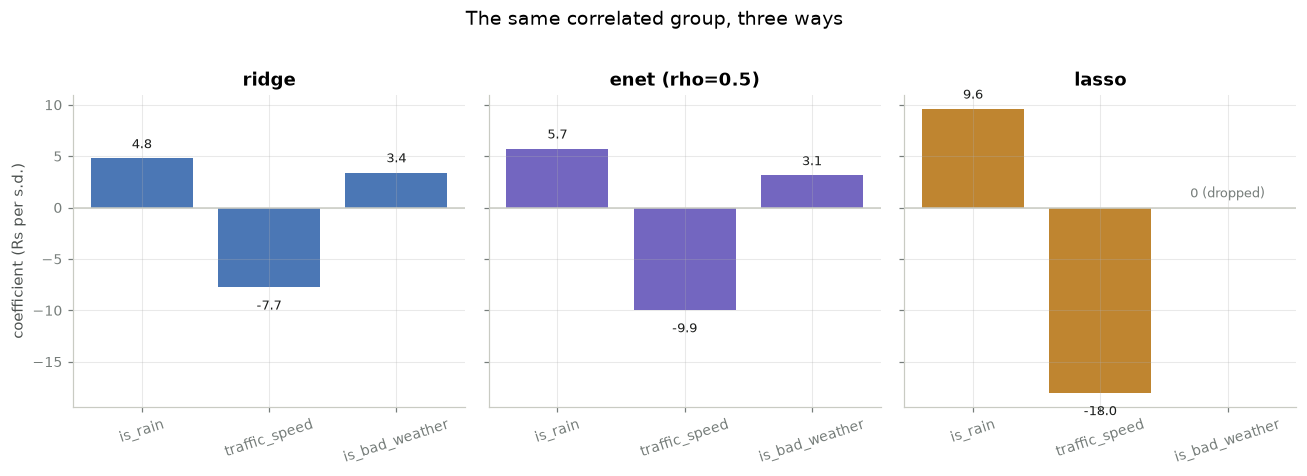

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for ax, (name, w) in zip(axes, fits.items()):
    vals = [w[FEATS.index(g)] for g in GROUP]
    col = C['ridge'] if 'ridge' in name else (C['enet'] if 'enet' in name else C['lasso'])
    bars = ax.bar([SHORT[g] for g in GROUP], vals, color=col, alpha=.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + (1 if v >= 0 else -2.2),
                '0 (dropped)' if abs(v) < 1e-8 else f'{v:.1f}',
                ha='center', fontsize=8.5,
                color='#767d7a' if abs(v) < 1e-8 else '#1b1d1c')
    ax.axhline(0, color='#c9cbc3', lw=1)
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=18)
axes[0].set_ylabel('coefficient (Rs per s.d.)')
fig.suptitle('The same correlated group, three ways', y=1.02, fontsize=12.5)
plt.tight_layout(); plt.show()

> **What to look for.** Ridge spreads the weather signal across all three members. Lasso
> zeroes `is_bad_weather` and loads its weight onto `traffic_speed`. Elastic Net keeps all
> three at moderate values and still zeroes `is_weekend`: the thing Ridge cannot do and
> Lasso does too aggressively.
>
> If your run disagrees, say so and investigate. An honest negative result is worth more
> than a forced positive one.

## Step 4 — sweep the mixing ratio $\rho$

 rho  is_rain  traffic_speed  is_bad_weather  non_zero
 0.0     4.78          -7.72            3.41         9
 0.1     4.93          -8.05            3.41         9
 0.3     5.28          -8.85            3.35         8
 0.5     5.72          -9.93            3.13         8
 0.7     6.36         -11.63            2.50         8
 0.9     7.72         -15.15            0.48         8
 1.0     9.60         -17.99            0.00         7


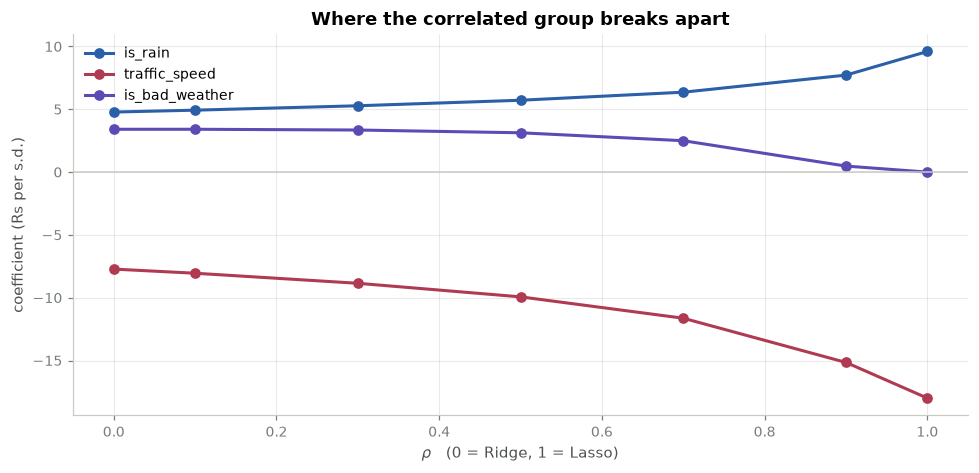

In [7]:
rhos = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
sweep = []
for rho in rhos:
    w = ridge_norm(Ztr, yc_tr, ALPHA) if rho == 0 else \
        coordinate_descent(Ztr, yc_tr, ALPHA, rho)[0]
    sweep.append({'rho': rho,
                  **{SHORT[g]: round(float(w[FEATS.index(g)]), 2) for g in GROUP},
                  'non_zero': int((np.abs(w) > 1e-8).sum())})
sw = pd.DataFrame(sweep)
print(sw.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.4))
for g, col in zip(GROUP, [C['ridge'], C['rose'], C['enet']]):
    ax.plot(sw.rho, sw[SHORT[g]], 'o-', color=col, lw=2, label=SHORT[g])
ax.axhline(0, color='#c9cbc3', lw=1)
ax.set(xlabel=r'$\rho$   (0 = Ridge, 1 = Lasso)', ylabel='coefficient (Rs per s.d.)',
       title='Where the correlated group breaks apart')
ax.legend()
plt.tight_layout(); plt.show()

## Step 5 — the bootstrap: measuring selection stability

"Lasso picks one of a correlated group at random" is a claim about variability across
resamples, so it cannot be checked on a single fit. Resample the training set with
replacement, refit, and count how often each feature survives.

In [8]:
rng = np.random.default_rng(42)
N_BOOT = 200
counts = {'lasso': np.zeros(len(FEATS)), 'enet': np.zeros(len(FEATS))}

for _ in range(N_BOOT):
    idx = rng.integers(0, len(yc_tr), len(yc_tr))
    Zb, yb = Ztr[idx], yc_tr[idx]
    yb = yb - yb.mean()
    for name, rho in [('lasso', 1.0), ('enet', 0.5)]:
        w, _ = coordinate_descent(Zb, yb, ALPHA, rho)
        counts[name] += (np.abs(w) > 1e-8)

stab = pd.DataFrame({
    'feature': [SHORT[f] for f in FEATS],
    'lasso_%': (100 * counts['lasso'] / N_BOOT).round(1),
    'enet_%': (100 * counts['enet'] / N_BOOT).round(1),
}).sort_values('lasso_%')
print(stab.to_string(index=False))

       feature  lasso_%  enet_%
is_bad_weather      0.0   100.0
    is_weekend      3.0    51.0
 drivers_avail     84.0   100.0
 open_requests     98.5   100.0
       is_peak    100.0   100.0
       is_rain    100.0   100.0
 traffic_speed    100.0   100.0
      is_event    100.0   100.0
    is_airport    100.0   100.0


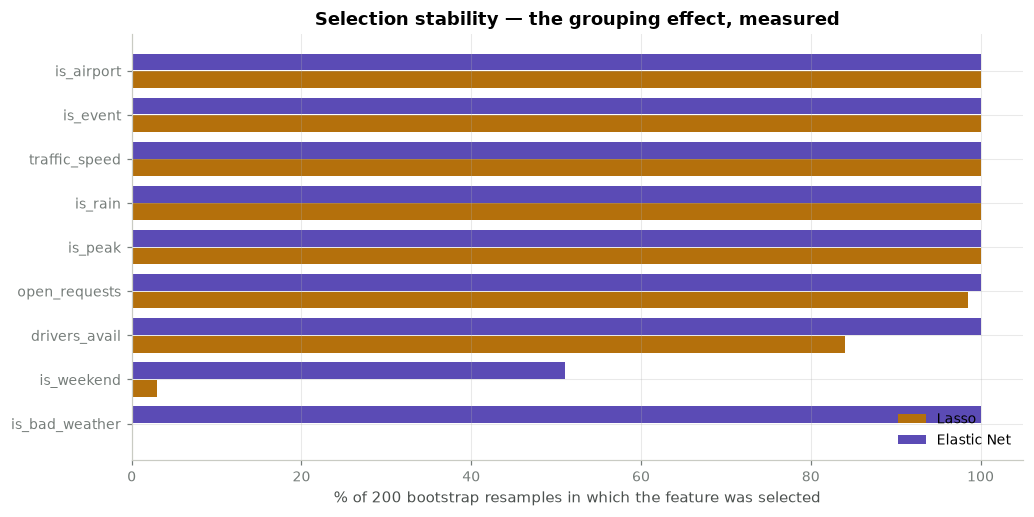

is_bad_weather: Lasso keeps it 0% of the time, Elastic Net 100%.
is_weekend    : Lasso keeps it 3% of the time, Elastic Net 51%.


In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ypos = np.arange(len(stab))
ax.barh(ypos - 0.2, stab['lasso_%'], height=0.38, color=C['lasso'], label='Lasso')
ax.barh(ypos + 0.2, stab['enet_%'], height=0.38, color=C['enet'], label='Elastic Net')
ax.set_yticks(ypos); ax.set_yticklabels(stab.feature)
ax.set(xlabel='% of 200 bootstrap resamples in which the feature was selected',
       xlim=(0, 105), title='Selection stability — the grouping effect, measured')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

bw = stab[stab.feature == 'is_bad_weather'].iloc[0]
wk = stab[stab.feature == 'is_weekend'].iloc[0]
print(f"is_bad_weather: Lasso keeps it {bw['lasso_%']:.0f}% of the time, "
      f"Elastic Net {bw['enet_%']:.0f}%.")
print(f"is_weekend    : Lasso keeps it {wk['lasso_%']:.0f}% of the time, "
      f"Elastic Net {wk['enet_%']:.0f}%.")

> **Read the whole table.** Elastic Net keeps the real group together, as expected. But
> `is_weekend` has a true coefficient of exactly zero, and Elastic Net keeps it far more
> often than Lasso does: its reluctance to zero anything is a cost as well as a benefit.
> A write-up that notices this has read the evidence.

### Cross-validated comparison, for Deliverable 2

In [10]:
def kfold_cv(Z, y, k, fit):
    n = len(y); idx = np.arange(n); tot = 0.0
    for f in range(k):
        te = np.zeros(n, bool); te[idx[f::k]] = True
        yb = y[~te].mean()
        w = fit(Z[~te], y[~te] - yb)
        tot += np.sum((y[te] - (Z[te] @ w + yb)) ** 2)
    return float(np.sqrt(tot / n))

grid = np.logspace(-3, 2.2, 40)
rows = []
for name, fit_at in [
        ('OLS', None),
        ('Ridge', lambda Z, t, a: ridge_norm(Z, t, a)),
        ('Lasso', lambda Z, t, a: coordinate_descent(Z, t, a, 1.0)[0]),
        ('Elastic Net', lambda Z, t, a: coordinate_descent(Z, t, a, 0.5)[0])]:
    if fit_at is None:
        a_best, w = None, np.linalg.solve(Ztr.T @ Ztr, Ztr.T @ yc_tr)
    else:
        scores = [kfold_cv(Ztr, ytr, 5, lambda Z, t, a=a: fit_at(Z, t, a)) for a in grid]
        a_best = float(grid[int(np.argmin(scores))])
        w = fit_at(Ztr, yc_tr, a_best)
    rows.append({'model': name, 'alpha': None if a_best is None else round(a_best, 4),
                 'train_rmse': round(rmse(ytr, Ztr @ w + ybar), 2),
                 'test_rmse': round(rmse(yte, Zte @ w + ybar), 2),
                 'test_r2': round(r2(yte, Zte @ w + ybar), 3),
                 'non_zero': int((np.abs(w) > 1e-8).sum()),
                 'dropped': ', '.join(SHORT[f] for f, v in zip(FEATS, w)
                                      if abs(v) < 1e-8) or '-'})
cmp_table = pd.DataFrame(rows)
print(cmp_table.to_string(index=False))
spread = cmp_table.test_rmse.max() - cmp_table.test_rmse.min()
print(f'\nBest and worst test RMSE differ by Rs {spread:.2f}.')

      model  alpha  train_rmse  test_rmse  test_r2  non_zero    dropped
        OLS    NaN        9.08      12.89    0.931         9          -
      Ridge 0.0117        9.09      12.92    0.931         9          -
      Lasso 0.1359        9.09      12.92    0.931         8 is_weekend
Elastic Net 0.0215        9.09      12.92    0.931         9          -

Best and worst test RMSE differ by Rs 0.03.


> **Deliverable 3 starts here.** If the spread is under a rupee or two on fares of several
> hundred, there is no statistically meaningful winner. Say so, then argue on operational
> grounds: a short fare breakdown, stability across refits, one hyperparameter versus two,
> and whether a feature vanishing after an overnight retrain is acceptable to the team that
> owns the model. Do not decide on the third decimal of RMSE.

---

### Checklist

- [ ] `is_bad_weather` built; both parent correlations reported
- [ ] Three estimators compared at a common $\alpha$, and CV-tuned
- [ ] $\rho$ sweep plotted; the break-up point identified
- [ ] **Bootstrap stability table and figure** (the graded step)
- [ ] Comparison table for Deliverable 2, with the RMSE spread quoted

Next: **Notebook 04 — the surge engine and the posterior**.